In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
job_array=False;index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [3]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [4]:
def averaged_profile_SE(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    SE=out_var[:, 0]
    zlevels=out_var[:, 2]
    return SE,zlevels

currently on type general
currently on type cloudy
currently on type general
currently on type cloudy


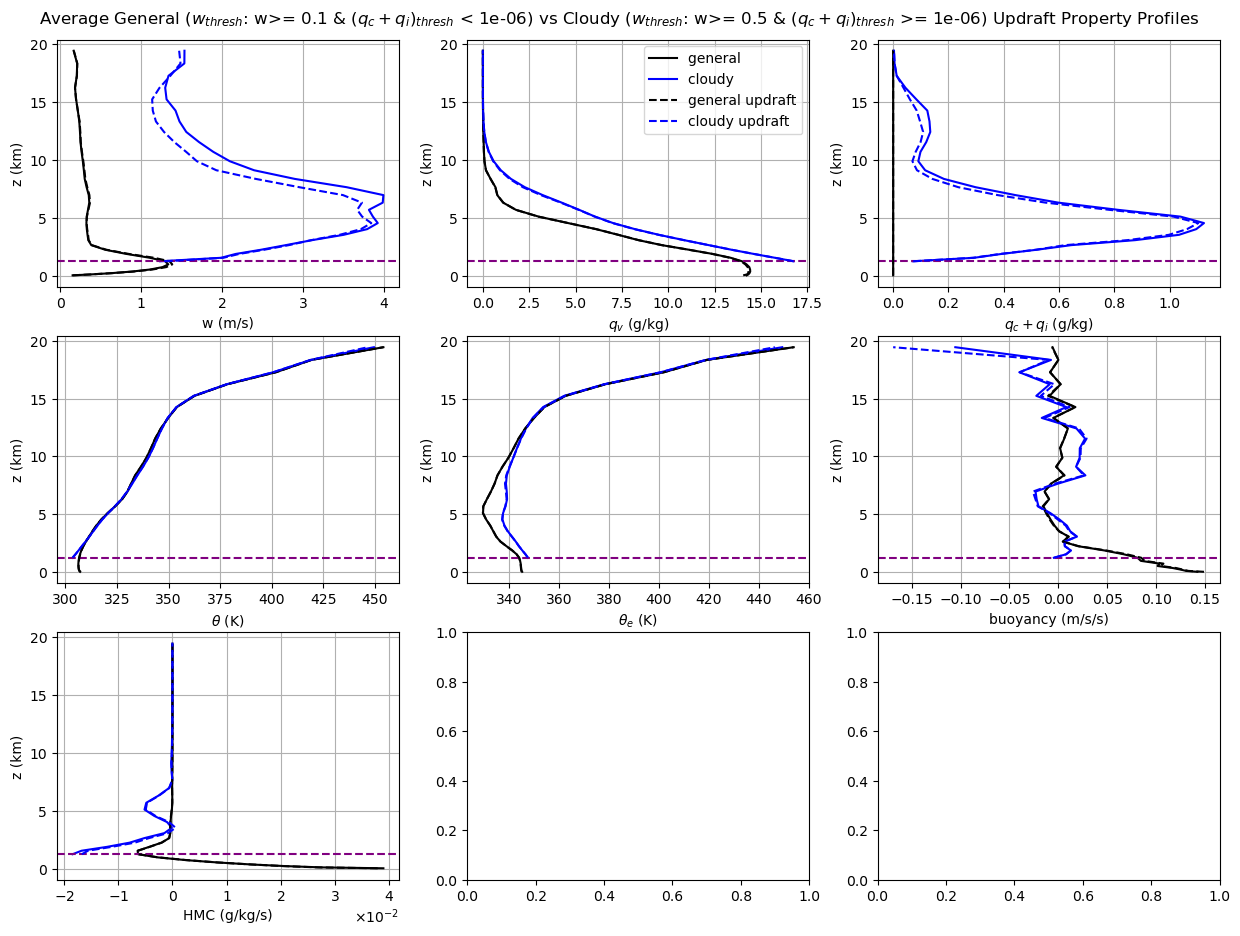

In [17]:
import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var
####################################################################

#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6

label=1

#Uses Plotting Function 
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle(f"Average General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Profiles")
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axs.flatten()
plt.subplots_adjust(top=0.95)  # Adjust the top margin
lw=0.8

####################################################################
#eulerian plotting
####################################################################
for type in ["general","cloudy"]:
    print(f'currently on type {type}')

    if type=='general':
        input_file = dir+f'Project_Algorithms/plots/job_out/general_eulerian_profiles_{res}_{Np_str}.h5'
        # input_file = dir+f'Project_Algorithms/plots/job_out/general_eulerian_profiles_CTRL_{res}_{Np_str}.h5'
    elif type=='cloudy':
        input_file = dir+f'Project_Algorithms/plots/job_out/cloudy_eulerian_profiles_{res}_{Np_str}.h5' 
        # input_file = dir+f'Project_Algorithms/plots/job_outcloudy_eulerian_profiles_CTRL_{res}_{Np_str}.h5'

    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc = np.array(f['profile_qc'])
        profile_qi = np.array(f['profile_qi'])
        profile_th = np.array(f['profile_th'])
        profile_th_e = np.array(f['profile_th_e'])
        profile_buoyancy = np.array(f['profile_buoyancy'])
        profile_HMC = np.array(f['profile_HMC'])
    
    #Plotting function
    def plotting(out_var, axis, label, color,linestyle):
        axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color,linestyle=linestyle)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars=['w','qv','qc','th','th_e','buoyancy', 'HMC']
    # vars=['w'] #TESTING
    for var in vars:
        globals()[f"out_{var}"] = averaged_profiles(globals()[f"profile_{var}"])
    
    vars=['w','qv','qc','th','th_e','buoyancy','HMC'] 
    # vars=['w'] #TESTING
    axises=[ax1,ax2,ax3,ax4,ax5,ax6,ax7] #ax5
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)', 'HMC (g/kg/s)'] 
    for var,axis,xlabel in zip(vars,axises,xlabels):
        if type=='general':
            color='k'
        elif type=='cloudy':
            color='blue'

        #converts qv and qc from kg/kg=>g/kg
        if var in ['qv','qc','HMC']:
            globals()[f"out_{var}"][:,0]*=1000

        
        plotting(globals()[f"out_{var}"],axis,label=type+' ',color=color,linestyle='solid')
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);

        if axis==ax2:
            axis.legend(); #add legend

        if axis==ax7:
            apply_scientific_notation([axis])

#MEAN CLOUD BASE
qcqi_profile=averaged_profiles(profile_qc)
where_cloudbase=np.where(qcqi_profile[:,0]>=qcqi_thresh)[0][0]
cloudbase=qcqi_profile[where_cloudbase,1]
for axis in axises:
    axis.axhline(cloudbase,color='purple',linestyle='dashed')


####################################################################
#lagrangian plotting
####################################################################
for type in ["general", "cloudy"]:
    print(f'currently on type {type}')

    if type=='general':
        input_file = dir+f'Project_Algorithms/plots/job_out/general_lagrangian_profiles_{res}_{Np_str}.h5'
        # input_file2 = dir+f'Project_Algorithms/plots/job_out/general_lagrangian_SE_profiles_{res}_{Np_str}.h5' #***
    elif type=='cloudy':
        input_file = dir+f'Project_Algorithms/plots/job_out/cloudy_lagrangian_profiles_{res}_{Np_str}.h5' 
        # input_file2 = dir+f'Project_Algorithms/plots/job_out/cloudy_lagrangian_SE_profiles_{res}_{Np_str}.h5' #***
    
    
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])
        profile_qv = np.array(f['profile_qv'])
        profile_qc_plus_qi = np.array(f['profile_qc_plus_qi'])
        profile_th = np.array(f['profile_th'])
        profile_th_e = np.array(f['profile_th_e'])
        profile_buoyancy = np.array(f['profile_buoyancy']) 
        profile_HMC = np.array(f['profile_HMC']) 
        
    # with h5py.File(input_file2, 'r') as f: #***
    #     SE_profile_w = np.array(f['SE_profile_w'])
    #     SE_profile_qv = np.array(f['SE_profile_qv'])
    #     SE_profile_qc_plus_qi = np.array(f['SE_profile_qc_plus_qi'])
    #     SE_profile_th = np.array(f['SE_profile_th'])
    #     SE_profile_th_e = np.array(f['SE_profile_th_e'])
    #     SE_profile_buoyancy = np.array(f['SE_profile_buoyancy']) 
    #     SE_profile_HMC = np.array(f['SE_profile_HMC']) 

    
    for var in ['qv','qc_plus_qi','HMC']:
        globals()[f"profile_{var}"][:,0]*=1000
        # globals()[f"SE_profile_{var}"][:,0]*=1000 #****
    
    # Plotting function
    def plotting(out_var, axis, label, color,linestyle):
        axis.plot(out_var[:, 0], out_var[:, 1], label=label, color=color,linestyle=linestyle)
        axis.grid(True)
    
    # Uses Averaged_Profiles Function
    vars = ['w', 'qv', 'qc_plus_qi', 'th','th_e','buoyancy','HMC']
    for var in vars:
        globals()[f"out_{var}"] = averaged_profiles(globals()[f"profile_{var}"])
    
    axises = [ax1, ax2, ax3, ax4, ax5, ax6, ax7]
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)','HMC (g/kg/s)'] #qi (g/kg)
    for var, axis, xlabel in zip(vars, axises, xlabels):
        if type == 'general':
            color = 'k'
        elif type == 'cloudy':
            color = 'blue'
 
        plotting(globals()[f"out_{var}"], axis, label=type + ' updraft', color=color,linestyle='dashed')
        # ####################################### #***
        # profile=globals()[f"out_{var}"]
        # SE_profile=globals()[f"SE_profile_{var}"]; SE=averaged_profile_SE(SE_profile)
        # axis.fill_betweenx(profile[:, 1], profile[:, 0] - 1.96*SE[0], profile[:, 0] + 1.96*SE[0], color=color, alpha=0.1)
        # ####################################### 
        
        axis.set_ylabel('z (km)')
        axis.set_xlabel(xlabel)
        if axis==ax2:
            axis.legend()  # add legend

        if axis==ax7:
            apply_scientific_notation([axis])
############################

#save plot

plt.savefig(dir+f'Project_Algorithms/plots/eulerian+lagrangian_generalvscloudy_updraft_profile_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) #uncomment if "general updrafts"


In [14]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

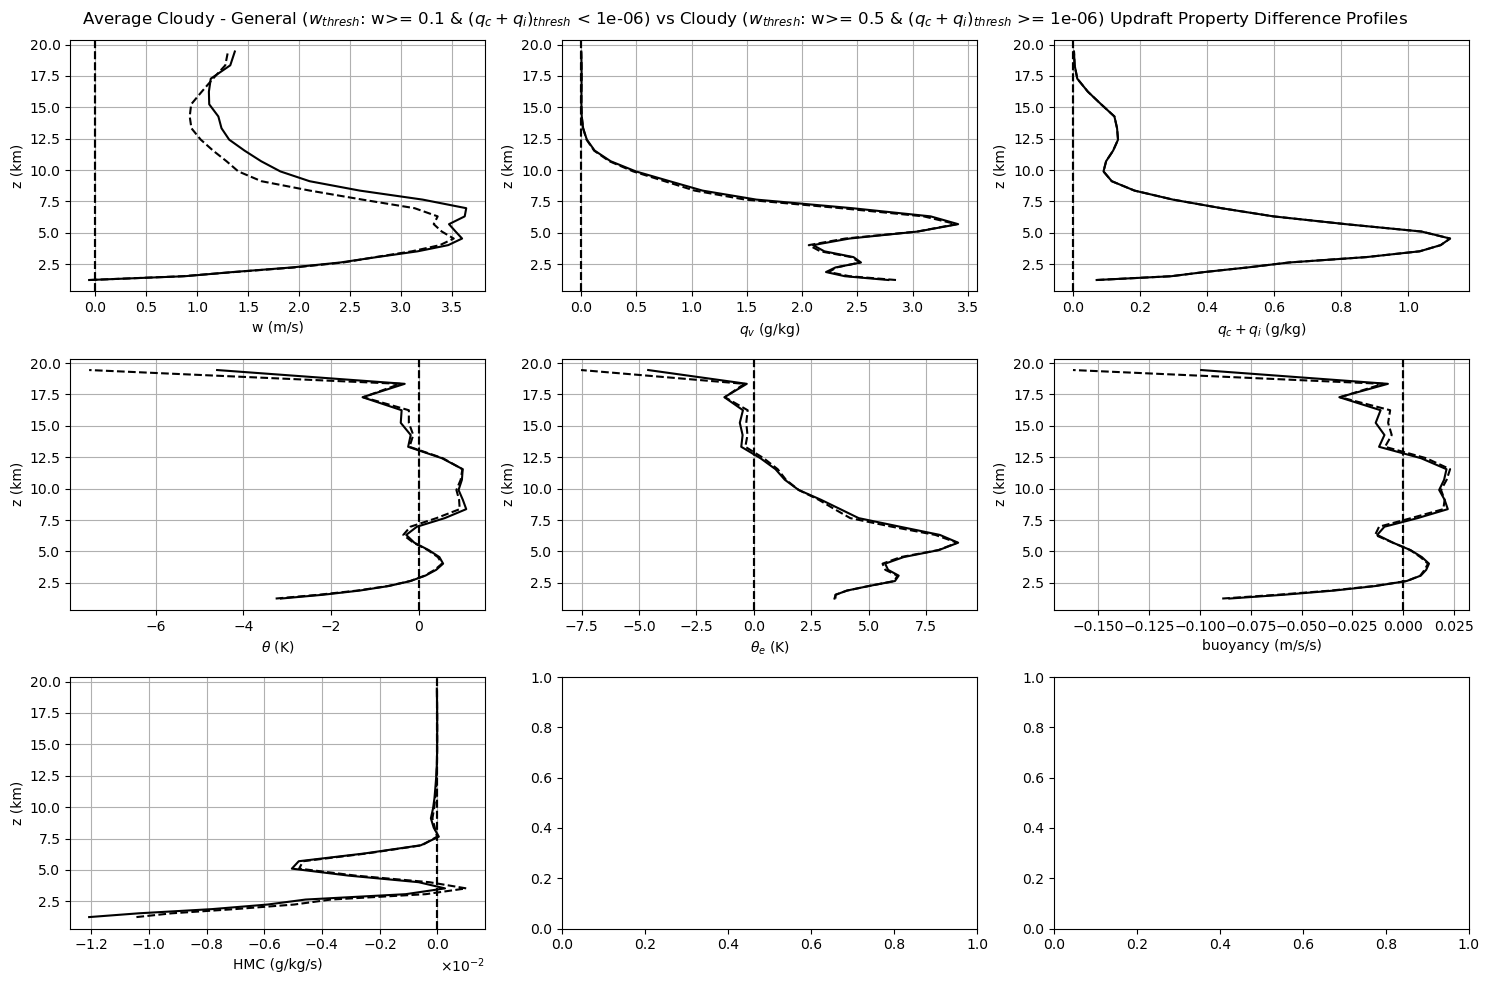

In [20]:
#Plotting Differences

#setting up figure
fig, axs = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle(f"Average Cloudy - General (" + r"$w_{thresh}$: w>= " + f"{w_thresh1} & " + r"$(q_c+q_i)_{thresh}$ < " + f"{qcqi_thresh}" + ") vs Cloudy (" + r"$w_{thresh}$: w>= " + f"{w_thresh2} & " + r"$(q_c+q_i)_{thresh}$ >= " + f"{qcqi_thresh}" + ") Updraft Property Difference Profiles")
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9 = axs.flatten()

#thresholds
w_thresh1=0.1
w_thresh2=0.5
qcqi_thresh=1e-6

label=1

####################################################################
#eulerian plotting
####################################################################
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

    
def get_data(type):

    if type=='general':
        input_file = dir+f'Project_Algorithms/plots/job_out/general_eulerian_profiles_{res}_{Np_str}.h5'
    elif type=='cloudy':
        input_file = dir+f'Project_Algorithms/plots/job_out/cloudy_eulerian_profiles_{res}_{Np_str}.h5'
    
    with h5py.File(input_file, 'r') as f:
        globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
        globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
        globals()[f'{type}_profile_qc'] = np.array(f['profile_qc'])
        globals()[f'{type}_profile_qi'] = np.array(f['profile_qi'])
        globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
        globals()[f'{type}_profile_th_e'] = np.array(f['profile_th_e'])
        globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])
        globals()[f'{type}_profile_HMC'] = np.array(f['profile_HMC'])
    
def diff_plotting():
    #the plotting
    vars=['w','qv','qc','th','th_e','buoyancy','HMC']
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)','HMC (g/kg/s)'] #qi (g/kg)
    for xlabel,var in zip(xlabels,vars):
        
        if var=='w':axis=ax1
        elif var=='qv':axis=ax2
        elif var=='qc':axis=ax3
        elif var=='th':axis=ax4
        elif var=='th_e':axis=ax5
        elif var=='buoyancy':axis=ax6
        elif var=='HMC':axis=ax7

        #get profile
        types=['cloudy','general']
        get_data(types[0])
        out_var_one=globals()[f"{types[0]}_profile_{var}"]
        get_data(types[1])
        out_var_two=globals()[f"{types[1]}_profile_{var}"]

        #finding where cloudy updraft count goes below 10
        cutofflow=np.where(out_var_one[:,1]>10)[0][0]
        cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
       
        #averaging
        out_var_diff=average_difference(out_var_one,out_var_two)

        #converts qv and qc from kg/kg=>g/kg
        if var in ['qv','qc','qi','HMC']:
            out_var_diff[:,0]*=1000
        
        axis.plot(out_var_diff[:,0],out_var_diff[:,-1],color='k')
        axis.axvline(0,color='k',linestyle='dashed')
        # axis.set_ylim(bottom=0,top=20)
        ## axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
        #labeling
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.grid(True)
        # axis.legend(fontsize='small') #only adds legend at final variable

        if axis==ax7:
            apply_scientific_notation([axis])

        # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
    plt.tight_layout()

diff_plotting()


####################################################################
#lagrangian plotting
####################################################################

#Plotting Differences
def averaged_profiles(profile):
    out_var = profile[(profile[:, 1] != 0)]  # gets rid of rows that have no data
    out_var = np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T  # divides the data column by the counter column
    return out_var

def get_data(type):

    if type=='general':
        input_file = dir+f'Project_Algorithms/plots/job_out/general_lagrangian_profiles_{res}_{Np_str}.h5'
        # input_file = dir+f'Project_Algorithms/plots/job_out/general_eulerian_profiles_CTRL_{res}_{Np_str}.h5'
    elif type=='cloudy':
        input_file = dir+f'Project_Algorithms/plots/job_out/cloudy_lagrangian_profiles_{res}_{Np_str}.h5'
        # input_file = dir+f'Project_Algorithms/plots/job_out/cloudy_eulerian_profiles_CTRL_{res}_{Np_str}.h5'
    
    with h5py.File(input_file, 'r') as f:
        globals()[f'{type}_profile_w'] = np.array(f['profile_w'])
        globals()[f'{type}_profile_qv'] = np.array(f['profile_qv'])
        globals()[f'{type}_profile_qc_plus_qi'] = np.array(f['profile_qc_plus_qi'])
        globals()[f'{type}_profile_th'] = np.array(f['profile_th'])
        globals()[f'{type}_profile_th_e'] = np.array(f['profile_th_e'])
        globals()[f'{type}_profile_buoyancy'] = np.array(f['profile_buoyancy'])
        globals()[f'{type}_profile_HMC'] = np.array(f['profile_HMC'])


    
def diff_plotting():

    #the plotting
    vars=['w','qv','qc','th','th_e','buoyancy','HMC']
    xlabels=['w (m/s)',r'$q_v$ (g/kg)',r'$q_c + q_i$ (g/kg)',r'$\theta$ (K)',r'$\theta_e$ (K)','buoyancy (m/s/s)','HMC (g/kg/s)'] #qi (g/kg)
    for xlabel,var in zip(xlabels,vars):
        
        if var=='w':axis=ax1
        elif var=='qv':axis=ax2
        elif var=='qc':axis=ax3
        elif var=='th':axis=ax4
        elif var=='th_e':axis=ax5
        elif var=='buoyancy':axis=ax6
        elif var=='HMC':axis=ax7

        #get profile
        types=['cloudy','general']
        get_data(types[0])
        out_var_one=globals()[f"{types[0]}_profile_{var}"]
        get_data(types[1])
        out_var_two=globals()[f"{types[1]}_profile_{var}"]

        #finding where cloudy updraft count goes below 10
        cutofflow=np.where(out_var_one[:,1]>10)[0][0]
        cutoffhigh=np.where(out_var_one[:,1]>10)[0][-1]
       
        #averaging
        out_var_diff=average_difference(out_var_one,out_var_two)

        #converts qv and qc from kg/kg=>g/kg
        if var in ['qv','qc','qi','HMC']:
            out_var_diff[:,0]*=1000
        
        axis.plot(out_var_diff[:,0],out_var_diff[:,-1],color='k',linestyle='dashed')
        axis.axvline(0,color='k',linestyle='dashed')
        # axis.set_ylim(bottom=0,top=20)
        ## axis.set_ylim(bottom=data['zh'][cutofflow],top=data['zh'][cutoffhigh])
        #labeling
        axis.set_ylabel('z (km)');axis.set_xlabel(xlabel);
        axis.grid(True)
        # axis.legend(fontsize='small') #only adds legend at final variable

        if axis==ax7:
            apply_scientific_notation([axis])

        # axis.set_yticks(list(axis.get_yticks()) + [data['zh'][cutofflow]]) #TESTING
    plt.tight_layout()

diff_plotting() 


plt.savefig(dir+f'Project_Algorithms/plots/eulerian+lagrangian_updraft_profiles_diff_{res}_{Np_str}.jpg', bbox_inches='tight', dpi=300) 